# Review the feature selection

This notebook reads the results that notebook 00 saved. It explains which
network-flow features separate benign traffic from attacks, and why some
highly ranked features are not used.

All scores come from **training data only**, so the test set stays unused.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_FOLDER = PROJECT_ROOT / "artifacts/feature_selection"

## 1. The selection methods

| Method | What it measures |
| --- | --- |
| Correlation | the strength of a straight-line relation with the binary label |
| Mutual information | any relation with the binary label, also one that is not a straight line |
| Random Forest importance | how much a feature helps the trees separate the two classes |
| Combined score | the mean of the three scores after each one is scaled to 0-1 |

A second step then compares the features **with each other** and removes a
feature that repeats a better feature.

In [2]:
report_file = RESULT_FOLDER / "selected_features.json"
score_file = RESULT_FOLDER / "feature_scores.csv"
correlation_file = RESULT_FOLDER / "feature_correlation.csv"

if not report_file.exists():
    raise FileNotFoundError("Run notebooks/00_complete_pipeline.ipynb first.")

report = json.loads(report_file.read_text(encoding="utf-8"))
scores = pd.read_csv(score_file).set_index("feature")
correlation = pd.read_csv(correlation_file, index_col=0)
selected = report["selected_features"]

display(pd.Series({
    "Sample rows": report["sample_rows"],
    "Candidate features": report["candidate_features"],
    "Constant features removed": len(report["constant_features"]),
    "Repeated features removed": len(report["redundant_features"]),
    "Correlation limit": report["correlation_limit"],
    "Selected features": report["selected_feature_count"],
}).to_frame("value"))

,value
Sample rows,200000.00
Candidate features,69.00
Constant features removed,8.00
Repeated features removed,22.00
Correlation limit,0.95
Selected features,20.00


## 2. Constant features

A constant feature has the same value in every sampled flow, so it cannot
separate benign traffic from attacks. CIC-IDS2017 contains several such
columns, mostly the bulk-rate features that CICFlowMeter never fills.

In [3]:
display(pd.DataFrame({"constant_feature": report["constant_features"]}))

,constant_feature
0,Bwd PSH Flags
1,Bwd URG Flags
2,Fwd Avg Bytes/Bulk
3,Fwd Avg Packets/Bulk
4,Fwd Avg Bulk Rate
5,Bwd Avg Bytes/Bulk
6,Bwd Avg Packets/Bulk
7,Bwd Avg Bulk Rate


## 3. The selected features

In [4]:
display(scores[scores["selected"]].round(4))

,rank,correlation,mutual_information,random_forest,combined_score,redundant_with,selected
feature,,,,,,,
Packet Length Variance,1,0.8789,0.9664,1.0000,0.9484,NaN,True
Packet Length Std,2,0.9397,0.9692,0.8320,0.9136,NaN,True
Avg Bwd Segment Size,3,0.9736,0.8552,0.7507,0.8598,NaN,True
Bwd Packet Length Std,4,1.0000,0.6888,0.8895,0.8595,NaN,True
Average Packet Size,5,0.8568,1.0000,0.6760,0.8442,NaN,True
Destination Port,10,0.2656,0.7788,0.6145,0.5530,NaN,True
Fwd IAT Max,11,0.7650,0.6593,0.1268,0.5170,NaN,True
Fwd IAT Std,13,0.8238,0.5163,0.1245,0.4882,NaN,True
Subflow Bwd Bytes,14,0.0024,0.8749,0.5347,0.4706,NaN,True


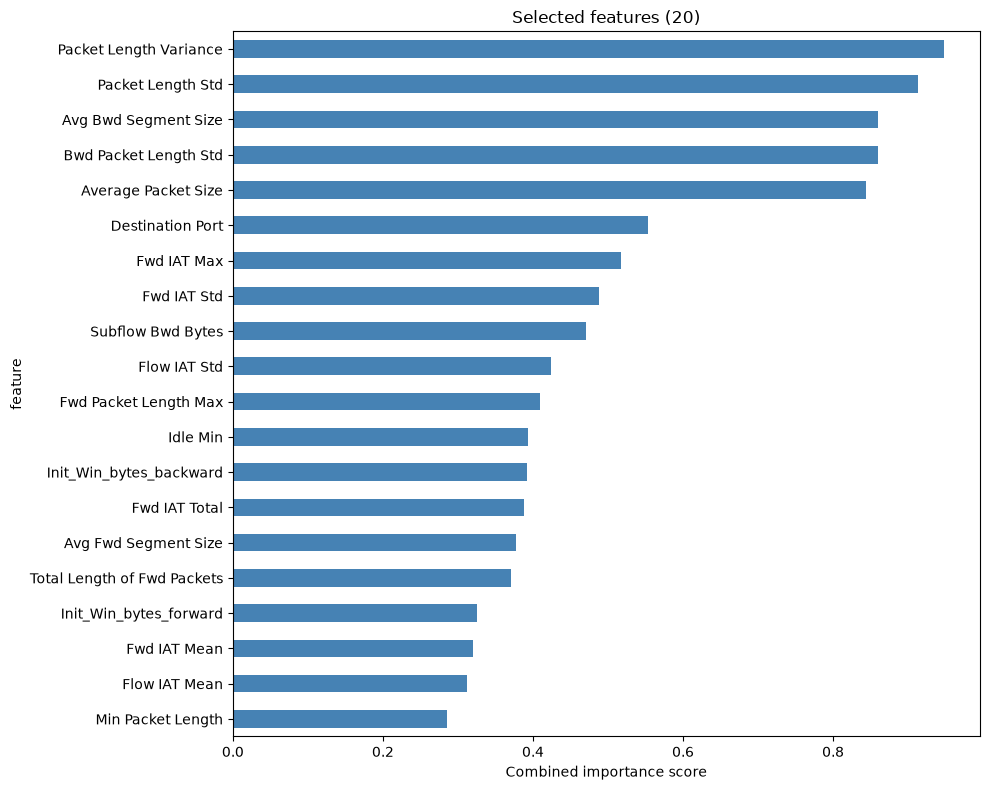

In [5]:
top = scores.loc[selected, "combined_score"].sort_values()
figure, axis = plt.subplots(figsize=(10, 8))
top.plot(kind="barh", color="steelblue", ax=axis)
axis.set_title(f"Selected features ({len(selected)})")
axis.set_xlabel("Combined importance score")
plt.tight_layout()
plt.show()

## 4. Compare the three methods

The three methods do not agree completely. Correlation only finds a
straight-line relation, so it gives a low score to a feature whose relation
with the label has another shape. The combined score uses all three, so one
method alone cannot control the result.

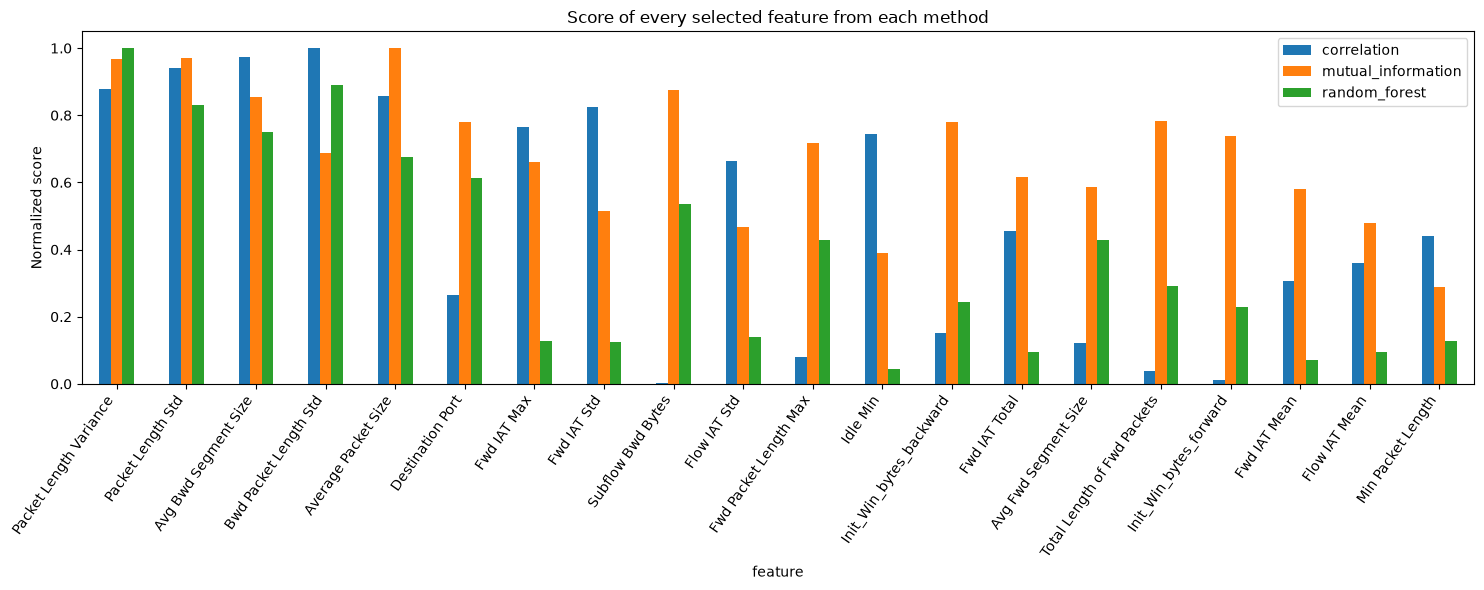

In [6]:
method_columns = ["correlation", "mutual_information", "random_forest"]
scores.loc[selected][method_columns].plot(kind="bar", figsize=(15, 6))
plt.title("Score of every selected feature from each method")
plt.ylabel("Normalized score")
plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

In [7]:
print("Agreement between the methods (correlation of the three score columns):")
display(
    scores[method_columns + ["combined_score"]].corr()
    .style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format(precision=2)
)

Agreement between the methods (correlation of the three score columns):


,correlation,mutual_information,random_forest,combined_score
correlation,1.00,0.47,0.56,0.83
mutual_information,0.47,1.00,0.74,0.85
random_forest,0.56,0.74,1.00,0.87
combined_score,0.83,0.85,0.87,1.00


## 5. Features that repeat each other

CIC-IDS2017 contains groups of features that measure the same quantity.
The table below lists every feature that the pipeline removed and the better
feature that it repeats. Without this step the twenty selected features
would contain pairs such as `Subflow Bwd Bytes` and
`Total Length of Bwd Packets`, which are equal. The model would then receive
fewer than twenty different signals.

In [8]:
removed = report["redundant_features"]
removed_table = pd.DataFrame({
    "removed feature": list(removed),
    "repeats": list(removed.values()),
})
removed_table["rank of removed"] = [
    int(scores.at[feature, "rank"]) for feature in removed_table["removed feature"]
]
removed_table["correlation"] = [
    round(abs(correlation.at[feature, keeper]), 4)
    for feature, keeper in zip(removed_table["removed feature"], removed_table["repeats"])
]
display(removed_table.sort_values("rank of removed").head(25))

,removed feature,repeats,rank of removed,correlation
0,Packet Length Mean,Average Packet Size,6,0.9978
1,Bwd Packet Length Max,Avg Bwd Segment Size,7,0.9583
2,Max Packet Length,Packet Length Std,8,0.9842
3,Bwd Packet Length Mean,Avg Bwd Segment Size,9,1.0000
4,Flow IAT Max,Fwd IAT Max,12,0.9980
5,Total Length of Bwd Packets,Subflow Bwd Bytes,15,1.0000
6,Idle Max,Fwd IAT Max,16,0.9886
7,Idle Mean,Fwd IAT Max,21,0.9780
8,Flow Duration,Fwd IAT Total,25,0.9985
9,Subflow Fwd Bytes,Total Length of Fwd Packets,26,1.0000


## 6. Correlation between the selected features

After the removal step, no pair of selected features has an absolute
correlation at or above the limit.

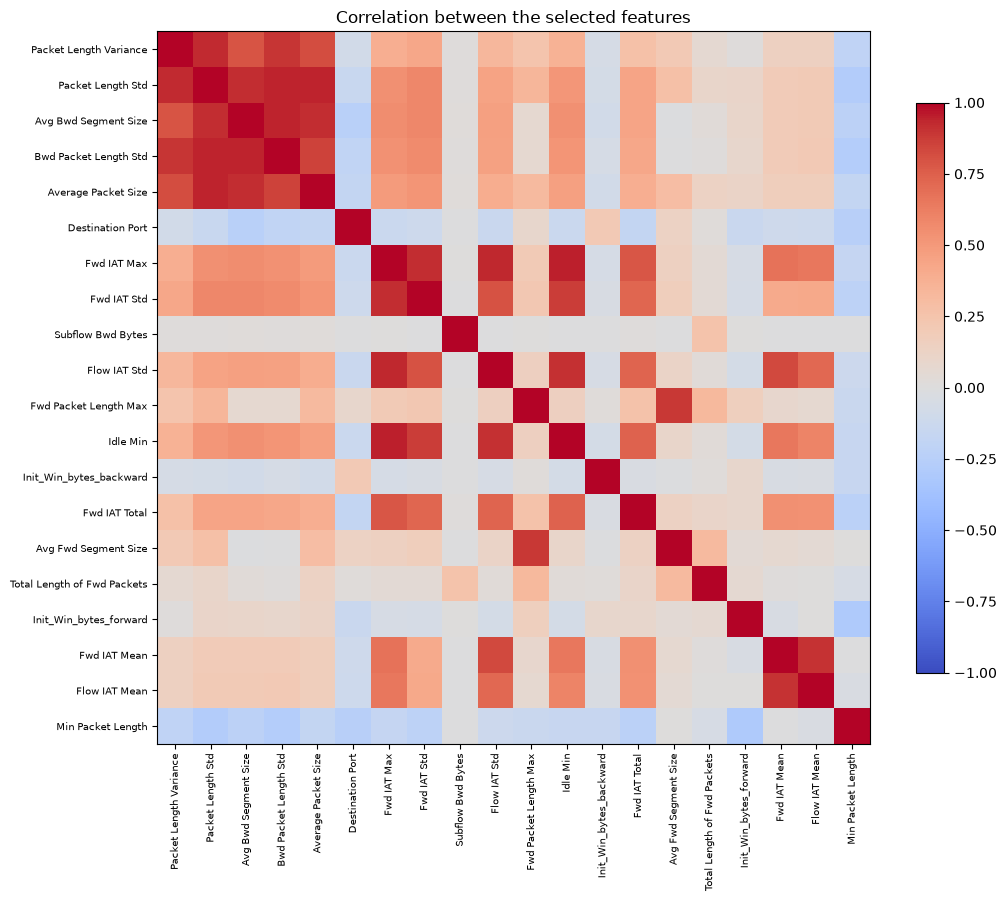

Largest absolute correlation between two selected features: 0.948
Limit used during selection: 0.95


In [9]:
matrix = correlation.loc[selected, selected]
figure, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(selected)), selected, rotation=90, fontsize=7)
axis.set_yticks(range(len(selected)), selected, fontsize=7)
axis.set_title("Correlation between the selected features")
figure.colorbar(image, ax=axis, shrink=0.8)
plt.tight_layout()
plt.show()

largest = matrix.where(~np.eye(len(matrix), dtype=bool)).abs().max().max()
print(f"Largest absolute correlation between two selected features: {largest:.3f}")
print(f"Limit used during selection: {report['correlation_limit']}")

## Conclusion

- The selected features are stored in `artifacts/feature_selection/selected_features.json`.
- Notebook 03 trains the binary models with these features.
- Notebook 04 reuses the same features for the attack-type model.
- The test set is used for the final measurement only.